Found 11000 images belonging to 110 classes.


c:\Users\Faqih SA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


344/344 ━━━━━━━━━━━━━━━━━━━━ 133s 386ms/step

Akurasi Model: 0.7086

Classification Report:
                                    precision  recall  f1-score       support
apple_pie                                0.52    0.53      0.53    100.000000
baby_back_ribs                           0.84    0.77      0.80    100.000000
baklava                                  0.67    0.82      0.74    100.000000
beef_tartare                             0.62    0.59      0.61    100.000000
beet_salad                               0.56    0.69      0.62    100.000000
beignet                                  0.71    0.91      0.79    100.000000
bibimbap                                 0.90    0.83      0.86    100.000000
black_beef_soup                          0.84    0.88      0.86    100.000000
bread_pudding                            0.63    0.61      0.62    100.000000
breakfast_burrito                        0.67    0.63      0.65    100.000000
bruschetta                               0.85    0

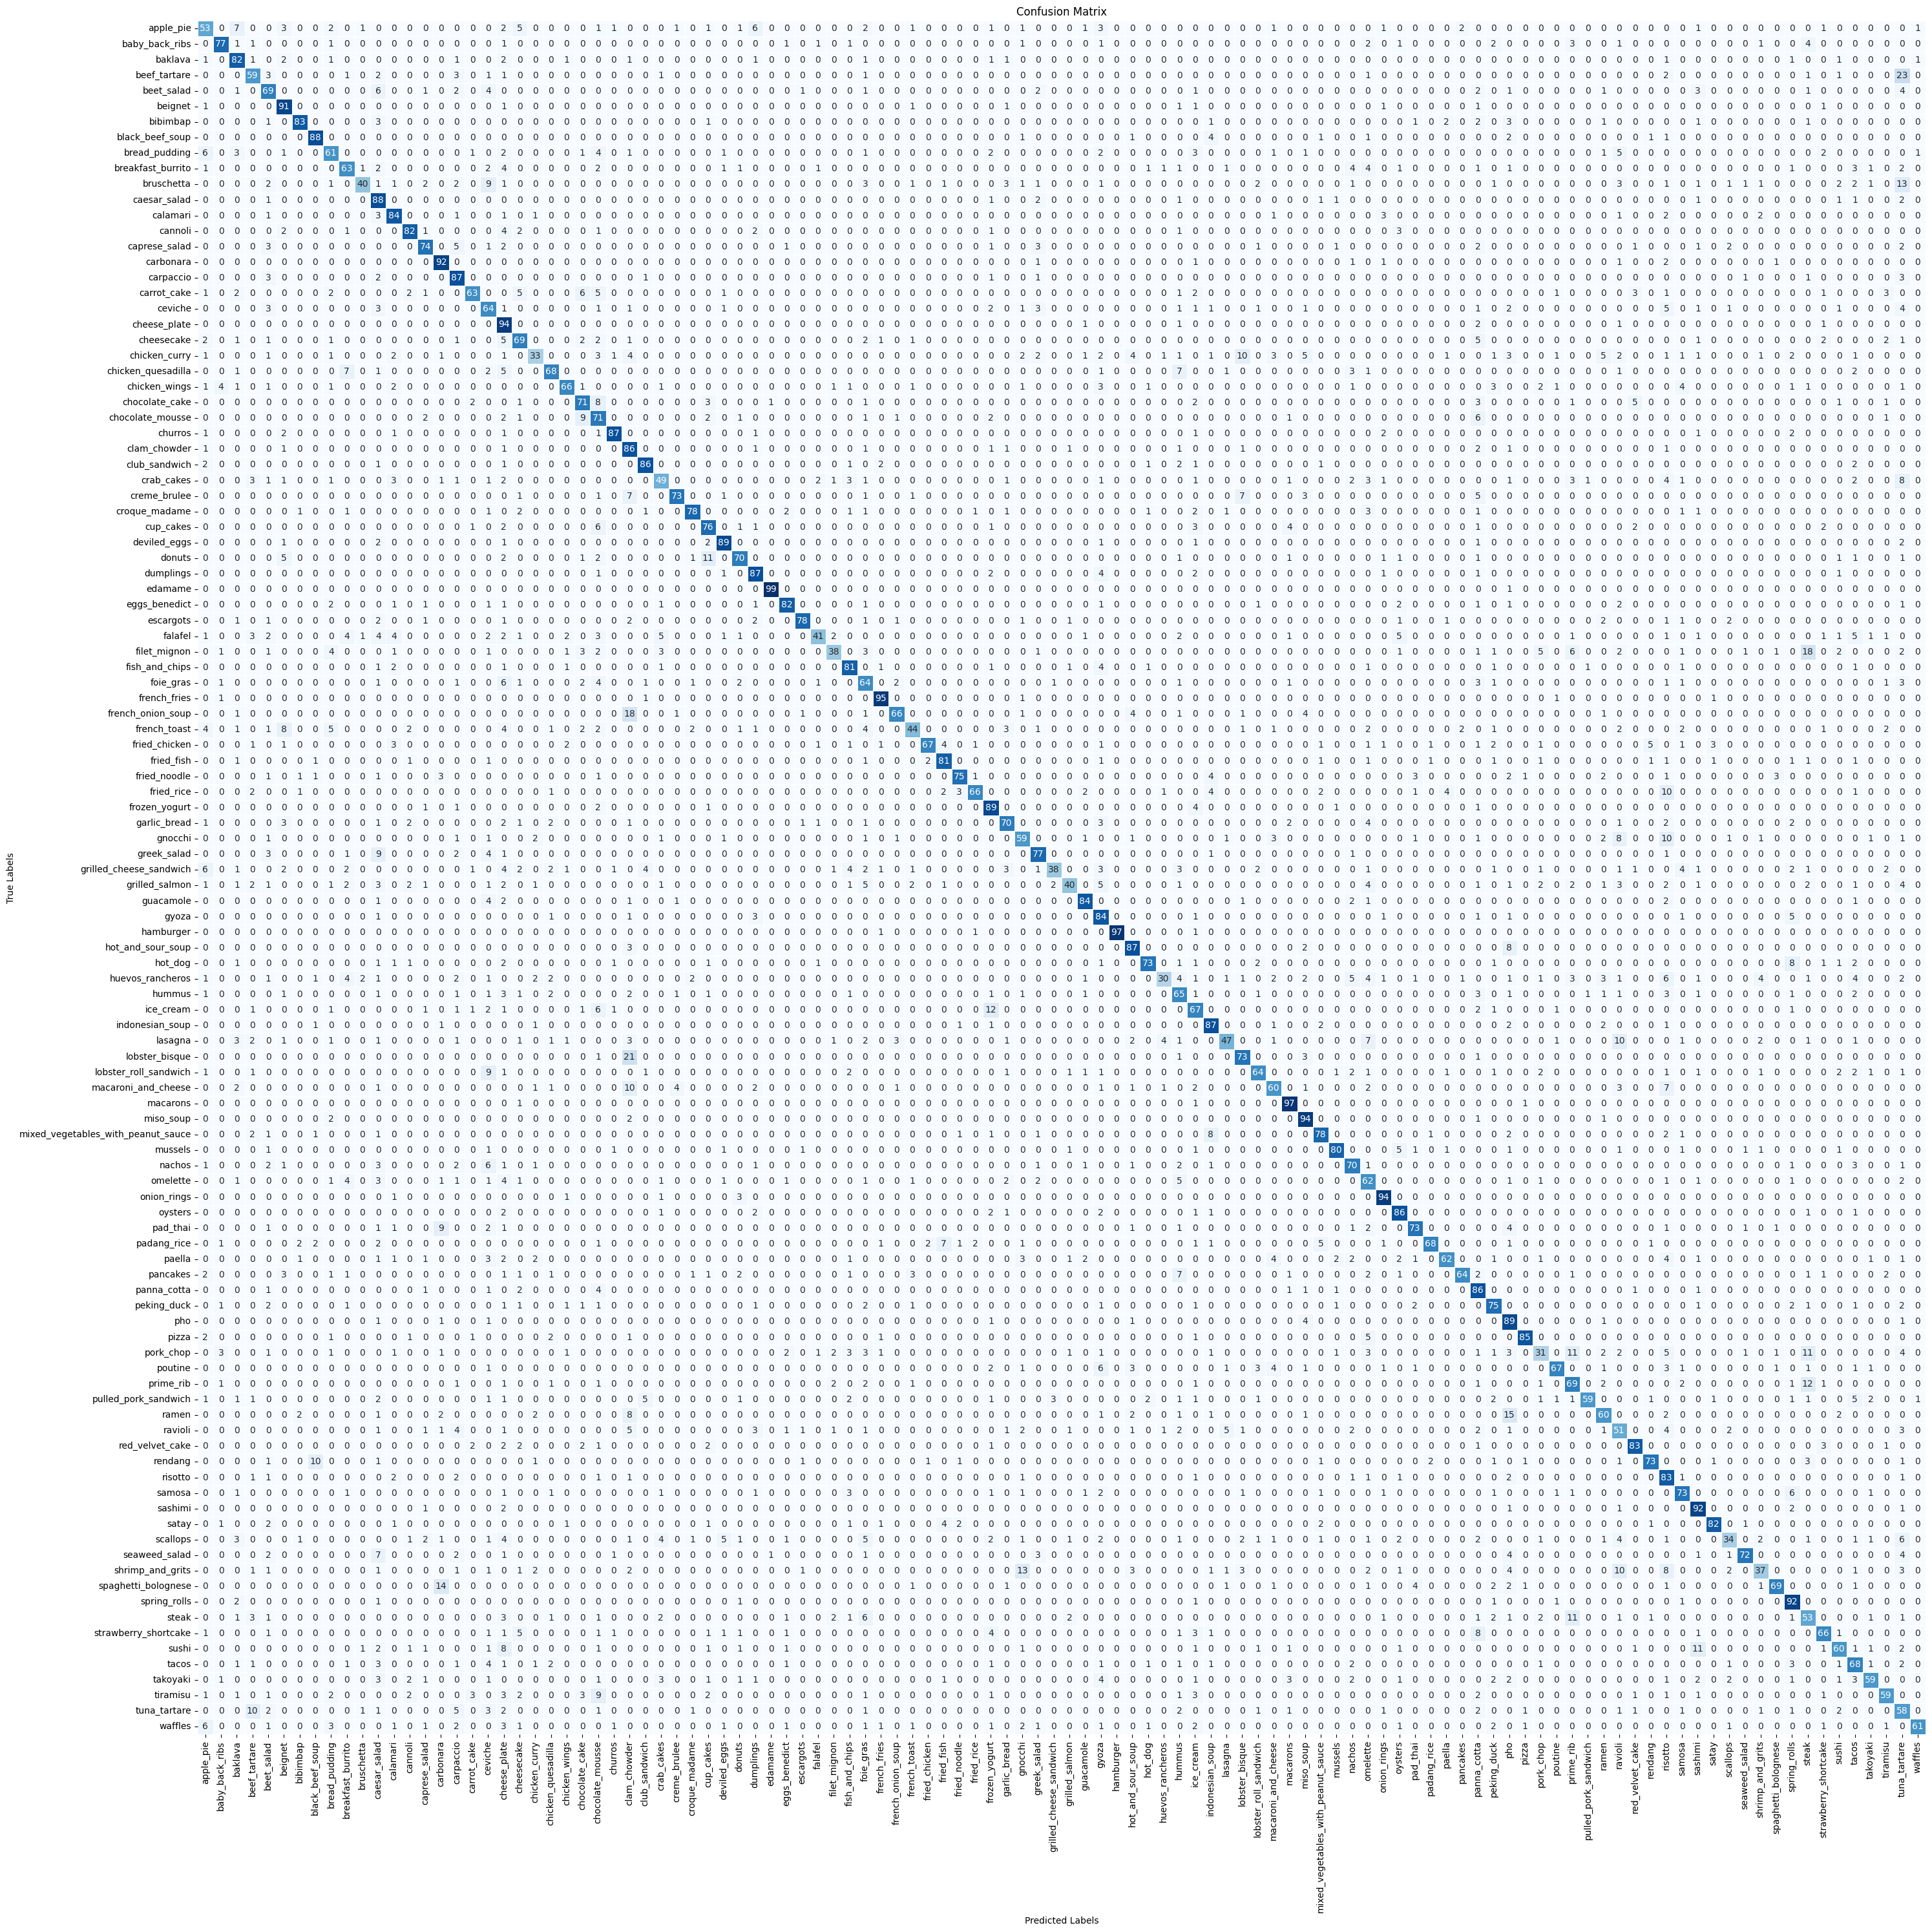

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load model
model = tf.keras.models.load_model('fullfood.keras')

# Direktori dataset uji
test_dir = 'foodtest'
image_size = (224, 224)
batch_size = 32

# ImageDataGenerator untuk data uji (tanpa augmentasi)
test_datagen = ImageDataGenerator(rescale=1./255)

# Generator data uji
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False  # jangan acak agar evaluasi sesuai urutan label
)

# Prediksi
predictions = model.predict(test_generator, verbose=1)
y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)
class_labels = list(test_generator.class_indices.keys())

# Hitung akurasi
accuracy = accuracy_score(y_true, y_pred)
print(f'\nAkurasi Model: {accuracy:.4f}')

# --- Classification Report ---
print("\nClassification Report:")
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Membulatkan ke 2 angka desimal (kecuali support dan akurasi)
for col in ['precision', 'recall', 'f1-score']:
    df_report[col] = df_report[col].apply(lambda x: round(x, 2))

# Menampilkan seluruh baris
pd.set_option('display.max_rows', None)
print(df_report)

# Jika ingin disimpan ke file:
# df_report.to_csv("classification_report.csv")

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(30, 30))
sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    cbar=False
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Load Model ---
model = tf.keras.models.load_model('fullfood.keras')

# --- Dataset Test ---
test_dir = 'foodtest'
image_size = (224, 224)
batch_size = 32

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# --- Prediksi ---
predictions = model.predict(test_generator, verbose=1)
y_true = test_generator.classes
y_pred = np.argmax(predictions, axis=1)
class_labels = list(test_generator.class_indices.keys())

# --- Akurasi ---
accuracy = accuracy_score(y_true, y_pred)
print(f'\nAkurasi Model: {accuracy:.4f}')

# --- Classification Report ---
report = classification_report(y_true, y_pred, target_names=class_labels, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# Bulatkan precision, recall, f1
for col in ['precision', 'recall', 'f1-score']:
    df_report[col] = df_report[col].apply(lambda x: round(x, 2))

print("\nClassification Report:")
print(df_report)

# --- Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred)

# 1) Confusion Matrix Global (Normalized)
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(20, 20))
sns.heatmap(
    cm_norm,
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=True,
    square=True
)
plt.title('Normalized Confusion Matrix (Global)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cm_normalized_global.png', dpi=600, bbox_inches='tight')
plt.close()

# 2) Confusion Matrix Subset (12 kelas F1-score terendah)
per_class = df_report.iloc[:-3]  # buang macro/micro/weighted avg
worst12 = per_class.sort_values('f1-score').head(12).index.tolist()
label_to_idx = {lbl: i for lbl, i in test_generator.class_indices.items()}
idxs = [label_to_idx[lbl] for lbl in worst12]

cm_sub = confusion_matrix(y_true, y_pred, labels=idxs, normalize='true')
plt.figure(figsize=(8, 8))
sns.heatmap(
    cm_sub,
    annot=True, fmt='.2f',
    cmap='Blues',
    xticklabels=worst12,
    yticklabels=worst12,
    cbar=True,
    square=True
)
plt.title('Confusion Matrix – 12 Kelas dengan F1-score Terendah')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('cm_subset_worst12.png', dpi=600, bbox_inches='tight')
plt.close()

# 3) Confusion Matrix dibagi per blok (20 kelas per blok)
def chunk(lst, n):
    for i in range(0, len(lst), n):
        yield lst[i:i+n]

block = 20
for b, block_labels in enumerate(chunk(class_labels, block), start=1):
    idxs = [test_generator.class_indices[lbl] for lbl in block_labels]
    cm_block = confusion_matrix(y_true, y_pred, labels=idxs, normalize='true')

    plt.figure(figsize=(10, 10))
    sns.heatmap(
        cm_block,
        annot=True, fmt='.2f',
        cmap='Blues',
        xticklabels=block_labels,
        yticklabels=block_labels,
        cbar=True,
        square=True
    )
    plt.title(f'Confusion Matrix – Blok {b}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'cm_block_{b}.png', dpi=600, bbox_inches='tight')
    plt.close()

print("\nConfusion Matrix berhasil dibuat:")
print("- cm_normalized_global.png (ringkasan global)")
print("- cm_subset_worst12.png (12 kelas F1-score terendah)")
print("- cm_block_X.png (blok per 20 kelas, untuk lampiran)")


Found 11000 images belonging to 110 classes.


c:\Users\Faqih SA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


344/344 ━━━━━━━━━━━━━━━━━━━━ 124s 357ms/step

Akurasi Model: 0.7086

Classification Report:
                precision  recall  f1-score       support
apple_pie            0.52    0.53      0.53    100.000000
baby_back_ribs       0.84    0.77      0.80    100.000000
baklava              0.67    0.82      0.74    100.000000
beef_tartare         0.62    0.59      0.61    100.000000
beet_salad           0.56    0.69      0.62    100.000000
...                   ...     ...       ...           ...
tuna_tartare         0.34    0.58      0.42    100.000000
waffles              0.94    0.61      0.74    100.000000
accuracy             0.71    0.71      0.71      0.708636
macro avg            0.74    0.71      0.71  11000.000000
weighted avg         0.74    0.71      0.71  11000.000000

[113 rows x 4 columns]

Confusion Matrix berhasil dibuat:
- cm_normalized_global.png (ringkasan global)
- cm_subset_worst12.png (12 kelas F1-score terendah)
- cm_block_X.png (blok per 20 kelas, untuk lampiran)


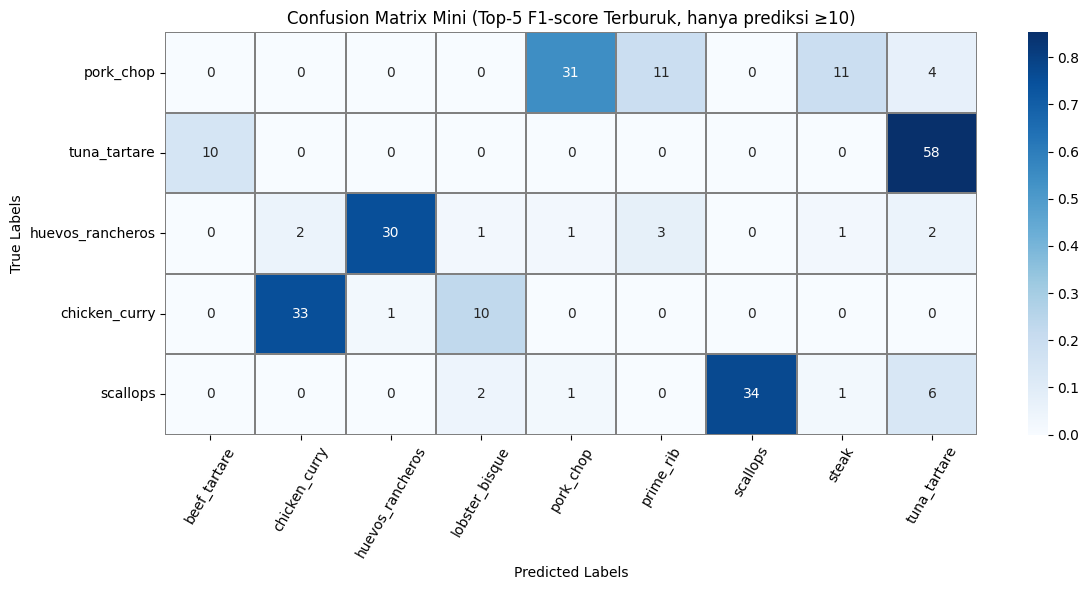

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- Hitung confusion matrix penuh ---
cm = confusion_matrix(y_true, y_pred)

# --- Ambil 5 kelas terburuk ---
df_classes = df_report.iloc[:-3]
worst_classes = df_classes.sort_values("f1-score").head(5).index.tolist()
worst_idx = [class_labels.index(c) for c in worst_classes]

# --- Subset confusion matrix (5 baris terburuk × semua kolom) ---
cm_worst = cm[worst_idx, :]

# --- Seleksi kolom: tampilkan hanya yg ada nilai >=10 di salah satu baris ---
mask_cols = (cm_worst >= 10).any(axis=0)   # True kalau kolom punya nilai >=10
selected_indices = np.where(mask_cols)[0]

# Tambahkan juga kolom "benar sendiri" biar terlihat diagonalnya
for i in worst_idx:
    if i not in selected_indices:
        selected_indices = np.append(selected_indices, i)

# Sort biar rapi
selected_indices = sorted(selected_indices)

cm_worst_sel = cm_worst[:, selected_indices]
sel_labels = [class_labels[j] for j in selected_indices]

# --- Normalisasi per baris untuk pewarnaan ---
row_sums = cm_worst_sel.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_worst_sel, row_sums, where=row_sums!=0)

# --- Plot heatmap mini dengan kolom terseleksi ---
plt.figure(figsize=(max(12, len(sel_labels)*0.6), 6))
sns.heatmap(
    cm_norm,
    annot=cm_worst_sel,
    fmt="g",
    cmap="Blues",
    xticklabels=sel_labels,
    yticklabels=worst_classes,
    cbar=True,
    linewidths=0.3,
    linecolor="gray"
)
plt.title("Confusion Matrix Mini (Top-5 F1-score Terburuk, hanya prediksi ≥10)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step


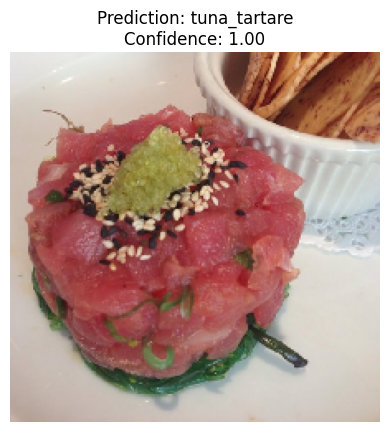

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Load the trained model
model = tf.keras.models.load_model('fullfood.keras')

# Replace this with your actual class labels
class_labels = [
    'apple_pie', 'baby_back_ribs', 'baklava', 'beef_tartare', 'beet_salad', 'beignet', 'bibimbap', 'black_beef_soup', 'bread_pudding', 'breakfast_burrito', 
    'bruschetta', 'caesar_salad', 'calamari', 'cannoli', 'caprese_salad', 'carbonara', 'carpaccio', 'carrot_cake', 'ceviche', 
    'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 
    'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame',
    'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 
    'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 
    'french_onion_soup', 'french_toast', 'fried_chicken', 'fried_fish', 'fried_noodle', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 
    'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 
    'ice_cream', 'indonesian_soup', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese', 'macarons', 
    'miso_soup', 'mixed_vegetables_with_peanut_sauce', 'mussels', 'nachos', 'omelette', 'onion_rings', 'oysters', 'pad_thai', 'padang_rice', 'paella', 
    'pancakes', 'panna_cotta', 'peking_duck', 'pho', 'pizza', 'pork_chop', 'poutine', 'prime_rib', 
    'pulled_pork_sandwich', 'ramen', 'ravioli',  'red_velvet_cake', 'rendang', 'risotto', 'samosa', 'sashimi', 'satay', 'scallops', 'seaweed_salad', 
    'shrimp_and_grits', 'spaghetti_bolognese', 'spring_rolls', 'steak', 'strawberry_shortcake', 
    'sushi', 'tacos', 'takoyaki', 'tiramisu', 'tuna_tartare', 'waffles'
]

def predict_image(img_path):
    # Load the image and preprocess it
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Rescale the image

    # Make prediction
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions, axis=1)[0]
    confidence_score = predictions[0][predicted_class]

    # Get the label of the predicted class
    predicted_label = class_labels[predicted_class]

    # Plot the image
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence_score:.2f}")
    plt.axis('off')
    plt.show()

# Replace this with the path to the image you want to classify
img_path = 'foodtest/tuna_tartare/3746815.jpg'
predict_image(img_path)
